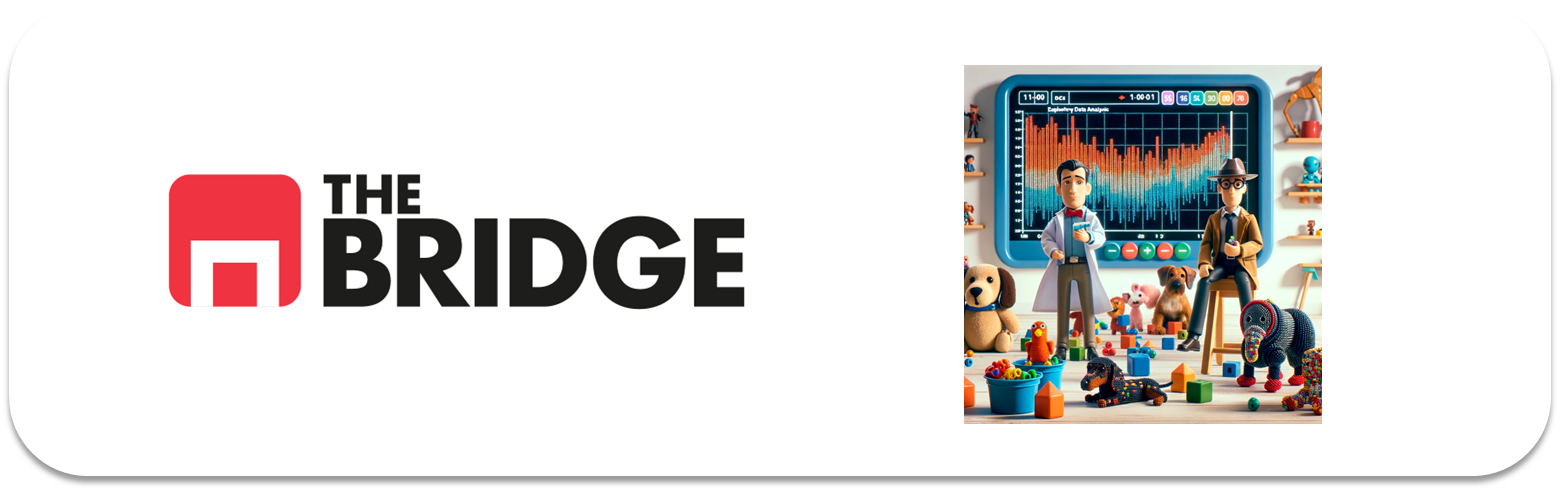

## PRACTICA OBLIGATORIA: **Análisis Multivariante**

* La práctica obligatoria de esta unidad consiste en completar el análisis del dataset del Titanic, dirigido por una serie de preguntas, y de terminar de analizar algunos aspectos del dataset de viajes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [17]:
# Yo lo importo todo por si acaso.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu

from bootcampviztools import plot_categorical_numerical_relationship, plot_categorical_relationship_fin, plot_combined_graphs, \
    pinta_distribucion_categoricas, plot_categorical_numerical_relationship, plot_grouped_boxplots, grafico_dispersion_con_correlacion

## #1: Titanic

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [3]:
# Cargamos el dataset
df_titanic = pd.read_csv("./data/titanic.csv")

In [4]:
df_titanic.sample(4)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
118,0,1,male,24.0,0,1,247.5208,C,First,man,True,B,Cherbourg,no,False
462,0,1,male,47.0,0,0,38.5000,S,First,man,True,E,Southampton,no,True
481,0,2,male,NaN,0,0,0.0000,S,Second,man,True,NaN,Southampton,no,True
114,0,3,female,17.0,0,0,14.4583,C,Third,woman,False,NaN,Cherbourg,no,True


In [5]:
df_titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [7]:
# Eliminamos las columnas indicadas
# Usamos df_titanic que es el nombre que le diste al cargar el archivo
df_titanic.drop(columns=["deck", "survived", "pclass", "embarked"], inplace=True)

# Comprobamos que ahora tenemos menos columnas y más claras
df_titanic.head()

,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone
0,male,22.0,1,0,7.2500,Third,man,True,Southampton,no,False
1,female,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False
2,female,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True
3,female,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False
4,male,35.0,0,0,8.0500,Third,man,True,Southampton,no,True


### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [8]:
# 1. Creamos la nueva columna sumando las dos existentes
df_titanic["family_members"] = df_titanic["sibsp"] + df_titanic["parch"]

# 2. Eliminamos las columnas originales para no tener información repetida
df_titanic.drop(columns=["sibsp", "parch"], inplace=True)

# 3. Mostramos el resultado
df_titanic.head()

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
0,male,22.0,7.2500,Third,man,True,Southampton,no,False,1
1,female,38.0,71.2833,First,woman,False,Cherbourg,yes,False,1
2,female,26.0,7.9250,Third,woman,False,Southampton,yes,True,0
3,female,35.0,53.1000,First,woman,False,Southampton,yes,False,1
4,male,35.0,8.0500,Third,man,True,Southampton,no,True,0


### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [11]:
# Calculamos la moda
moda_embark = df_titanic['embark_town'].mode()[0]

# Rellenamos asignando directamente (sin inplace)
df_titanic['embark_town'] = df_titanic['embark_town'].fillna(moda_embark)

print(f"Puerto más frecuente usado para imputar: {moda_embark}")

Puerto más frecuente usado para imputar: Southampton


### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [12]:
# Imputamos la media de edad según el grupo ('man', 'woman', 'child')
df_titanic['age'] = df_titanic.groupby('who')['age'].transform(lambda x: x.fillna(x.mean()))

# Verificamos que ya no quedan nulos
print(df_titanic.isnull().sum())

sex               0
age               0
fare              0
class             0
who               0
adult_male        0
embark_town       0
alive             0
alone             0
family_members    0
dtype: int64


### #1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

Apartado 1

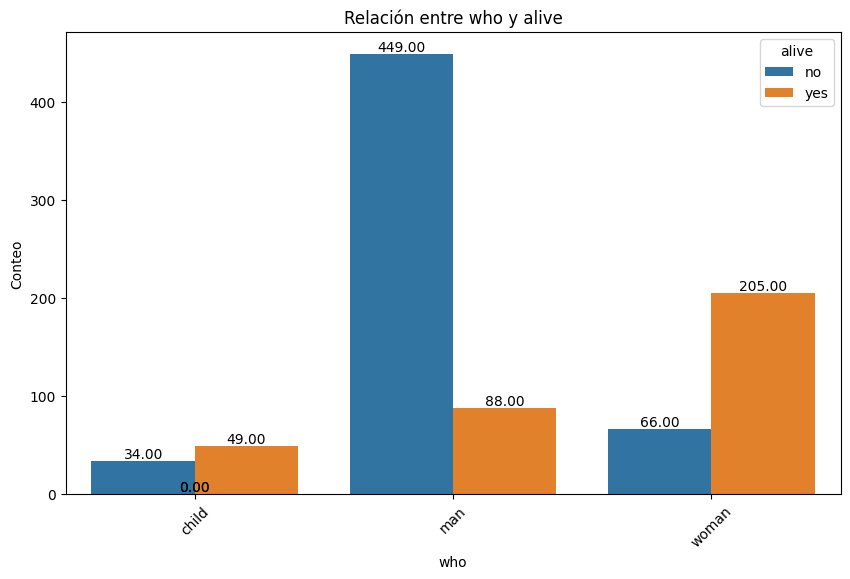

In [22]:
# Sobrevivieron más mujeres en términos absolutos. En términos relativos también.
# Sí, existe una relación significativa (mujeres: 76% y hombres: 16% de probabilidades de sobrevivir).
plot_categorical_relationship_fin(df_titanic, "who","alive", show_values= True)

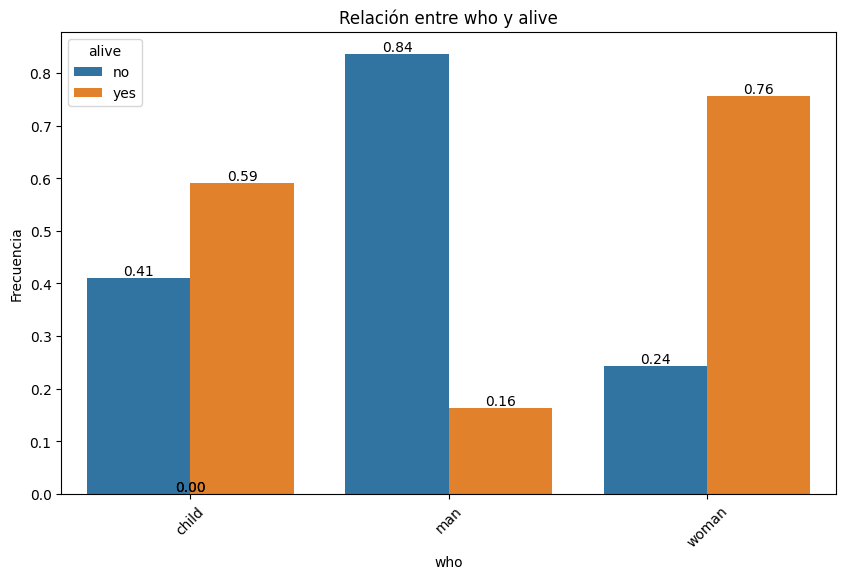

In [23]:
plot_categorical_relationship_fin(df_titanic, "who","alive", relative_freq= True, show_values= True)

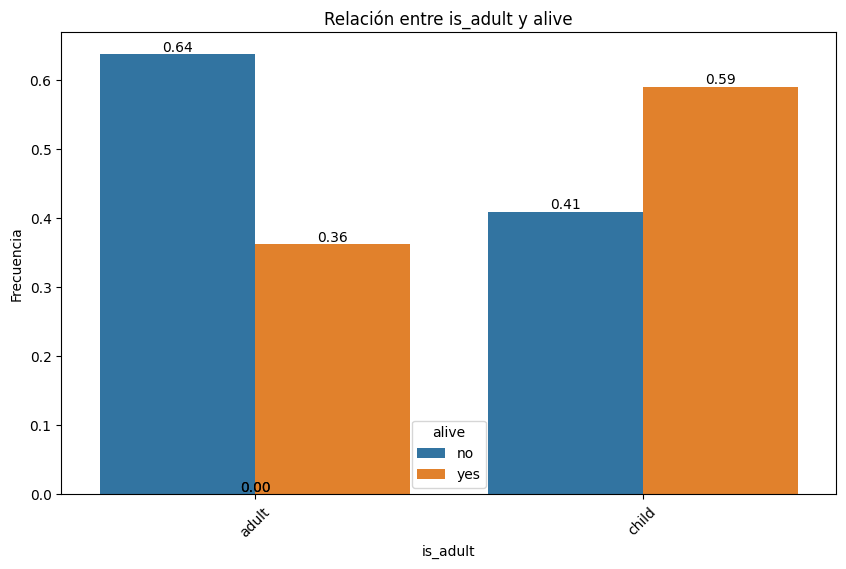

In [28]:
# 1. Creamos una columna temporal para agrupar
df_titanic['is_adult'] = df_titanic['who'].replace({'man': 'adult', 'woman': 'adult'})

# 2. Pintamos la relación relativa (Porcentaje)
plot_categorical_relationship_fin(df_titanic, "is_adult", "alive", relative_freq=True, show_values=True)

In [30]:
# Conclusión, han sobrevivido el 36% de los adultos y el 59% de los niños. Así que hay diferencia, casi un 23% más de supervivencia.

Apartado 2

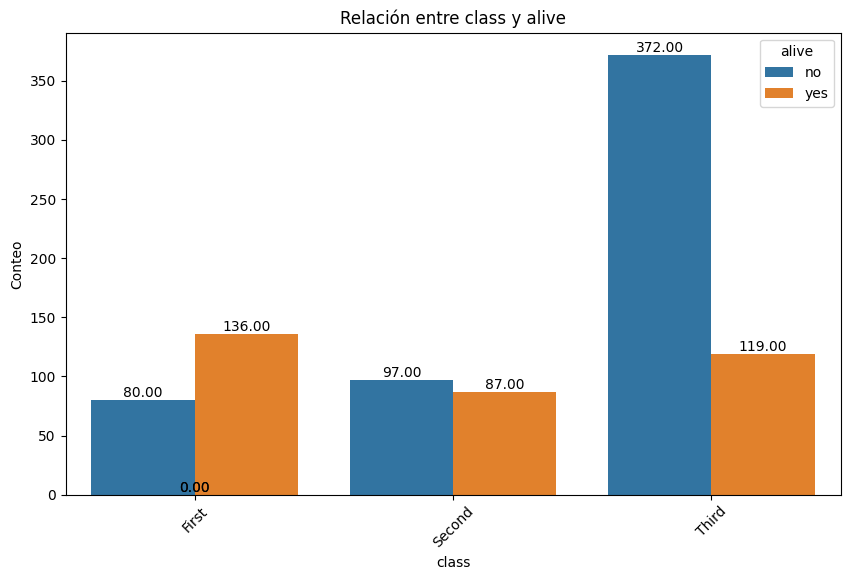

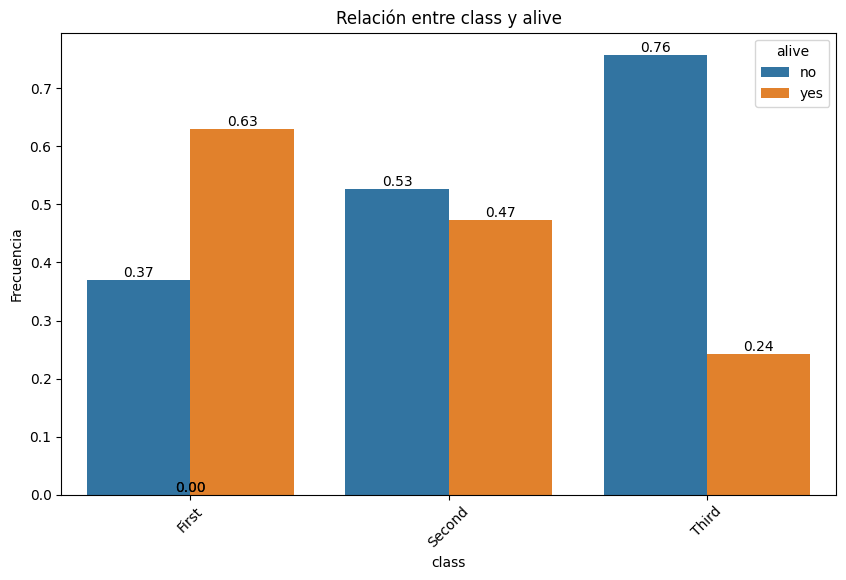

In [31]:
# Gráfico relativo de Clase vs Supervivencia
plot_categorical_relationship_fin(df_titanic, "class","alive", show_values= True)
plot_categorical_relationship_fin(df_titanic, "class", "alive", relative_freq=True, show_values=True)

In [32]:
# En términos absolutos: sobrevivieron más de primera clase(136). En términos relativos, también (63%)
# Existe una relación estadísticamente significativa. Viajar en una clase u otra determinaba tus posibilidades de supervivencia.
# La probabilidad de morir en tercera clase era el triple que en primera.

Apartado 3

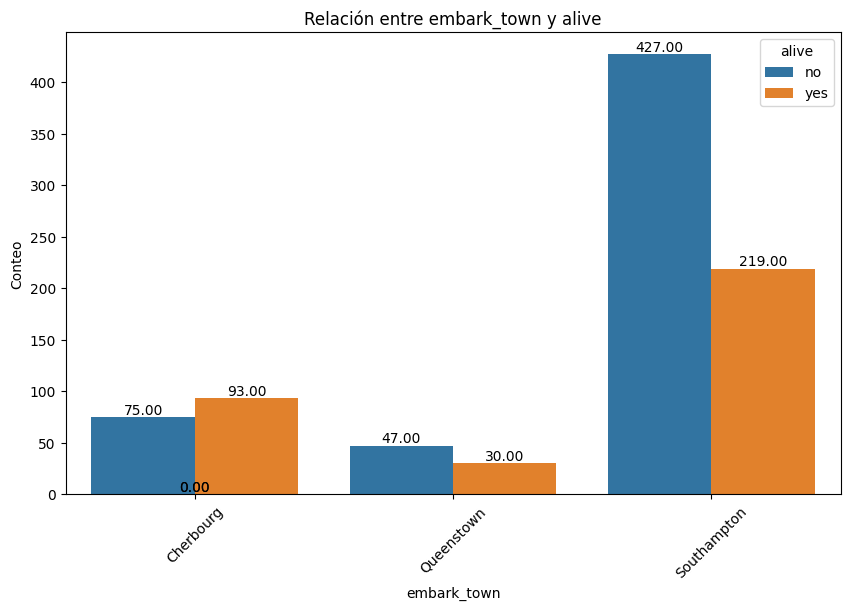

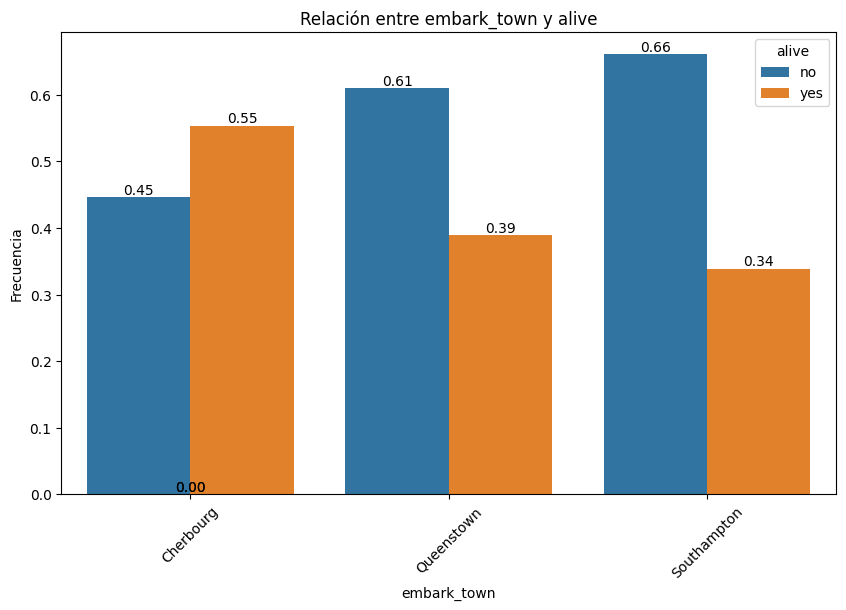

In [33]:
# 1. Absoluto
plot_categorical_relationship_fin(df_titanic, "embark_town", "alive", show_values=True)

# 2. Relativo
plot_categorical_relationship_fin(df_titanic, "embark_town", "alive", relative_freq=True, show_values=True)

In [35]:
# Sobrevivieron más personas de Southampton. Pero también porque había muchos más. Porcentualmente, sobrevivieron más personas de
# Cherbourg(el 55%). Hay una relación clara entre el puerto de embarque y la supervivencia.
# Luego habría que buscar el motivo, supongo.

Apartado 4

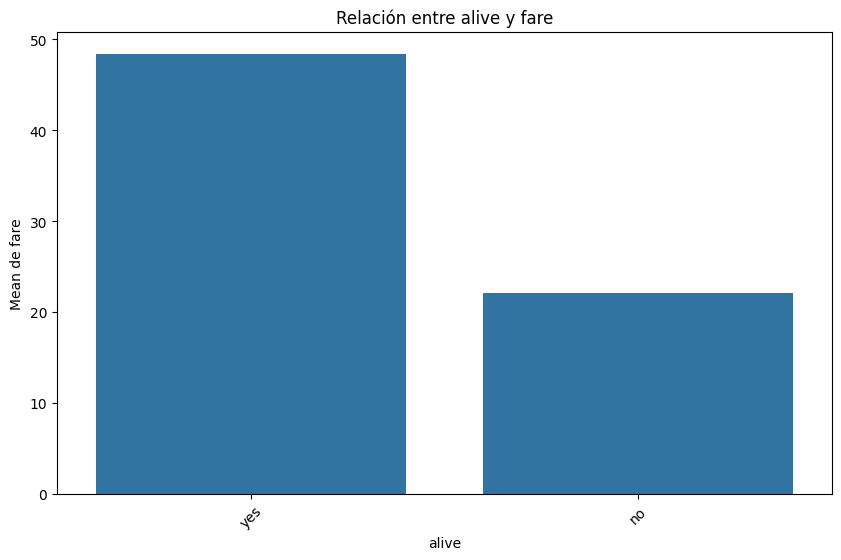

In [37]:
# Relación entre el precio (fare) y la supervivencia (alive)
plot_categorical_numerical_relationship(df_titanic, "alive", "fare")

In [38]:
# Existe una relación directa. Cuanto más caro era el billete, más probabilidades había de sobrevivir.

Apartado 5

In [46]:
# Filtramos los pasajeros que pagaron 0
gratis = df_titanic[df_titanic['fare'] == 0]
print(f"Número de pasajeros con billete gratis: {len(gratis)}")
gratis[['sex', 'age', 'class', 'embark_town', 'who', 'alive']]

Número de pasajeros con billete gratis: 15


,sex,age,class,embark_town,who,alive
179,male,36.000000,Third,Southampton,man,no
263,male,40.000000,First,Southampton,man,no
271,male,25.000000,Third,Southampton,man,yes
277,male,33.173123,Second,Southampton,man,no
302,male,19.000000,Third,Southampton,man,no
413,male,33.173123,Second,Southampton,man,no
466,male,33.173123,Second,Southampton,man,no
481,male,33.173123,Second,Southampton,man,no
597,male,49.000000,Third,Southampton,man,no
633,male,33.173123,First,Southampton,man,no


In [47]:
# Yo no sé por qué no pagaron, lo mismo eran polizones o trabajadores del barco.

In [48]:
# Buscamos el valor máximo de la tarifa
max_fare = df_titanic['fare'].max()
pasajero_rico = df_titanic[df_titanic['fare'] == max_fare]

print(f"La tarifa más alta fue de: {max_fare}")
pasajero_rico[['sex', 'age', 'class', 'embark_town', 'who', 'alive']]

La tarifa más alta fue de: 512.3292


,sex,age,class,embark_town,who,alive
258,female,35.0,First,Cherbourg,woman,yes
679,male,36.0,First,Cherbourg,man,yes
737,male,35.0,First,Cherbourg,man,yes


In [49]:
# El billete más caro costó 512.3292 (libras de la época). Hubo tres personas que pagaron esta tarifa (todos en Primera Clase y embarcados en Cherbourg).
# Todos sobrevivieron. Esto confirma de nuevo la relación directa entre el poder adquisitivo y las posibilidades de salvación en el Titanic.

Apartado 6

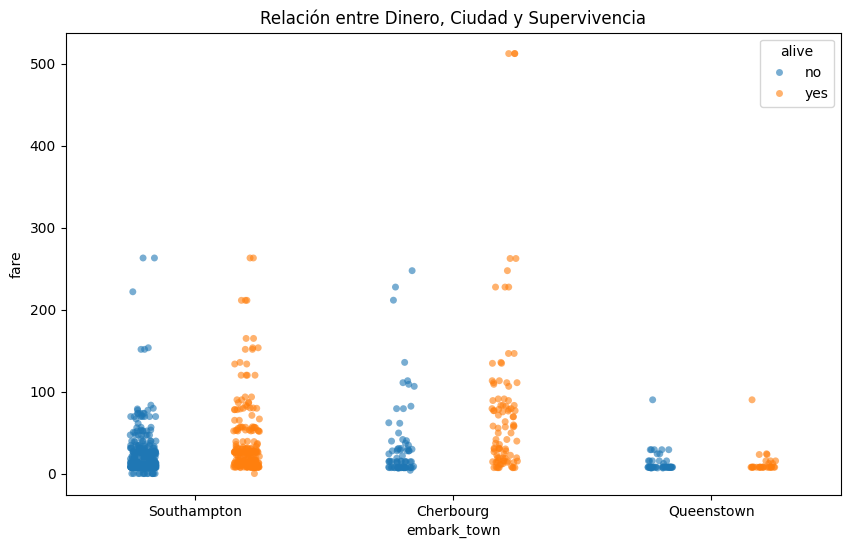

In [50]:
plt.figure(figsize=(10,6))
sns.stripplot(x="embark_town", y="fare", hue="alive", data=df_titanic, dodge=True, jitter=True, alpha=0.6)
plt.title("Relación entre Dinero, Ciudad y Supervivencia")
plt.show()

In [52]:
# Explicación de los argumentos de la megafunción:

# a) x="embark_town": Define el eje horizontal. En este caso, agrupa los puntos por la ciudad de embarque.
# b) y="fare": Define el eje vertical. Aquí se mide el precio del billete.
# c) hue="alive": Es el argumento del color. Divide los puntos en dos colores basándose en 'alive'.
# d) dodge=True: En lugar de mezclar los puntos de supervivientes y fallecidos en una sola columna vertical, los separa a los lados (uno a la izquierda y otro a la derecha) dentro de la misma ciudad. Así no se amontonan.
# e) jitter=True: Añade un poco de "ruido" o dispersión aleatoria horizontal a los puntos. Sin esto, si muchos pasajeros pagaron exactamente lo mismo (por ejemplo, 7.25), verías un solo punto gordo o una línea perfecta; con jitter, los puntos se separan un poco para que puedas ver cuántos hay realmente.
# f) alpha=0.6: Controla la transparencia de los puntos (va de 0 a 1). Al poner 0.6, los puntos son ligeramente transparentes. Esto sirve para que, si hay muchos puntos uno encima de otro, las zonas más oscuras te indiquen que ahí hay una mayor concentración de pasajeros.

Apartado 7

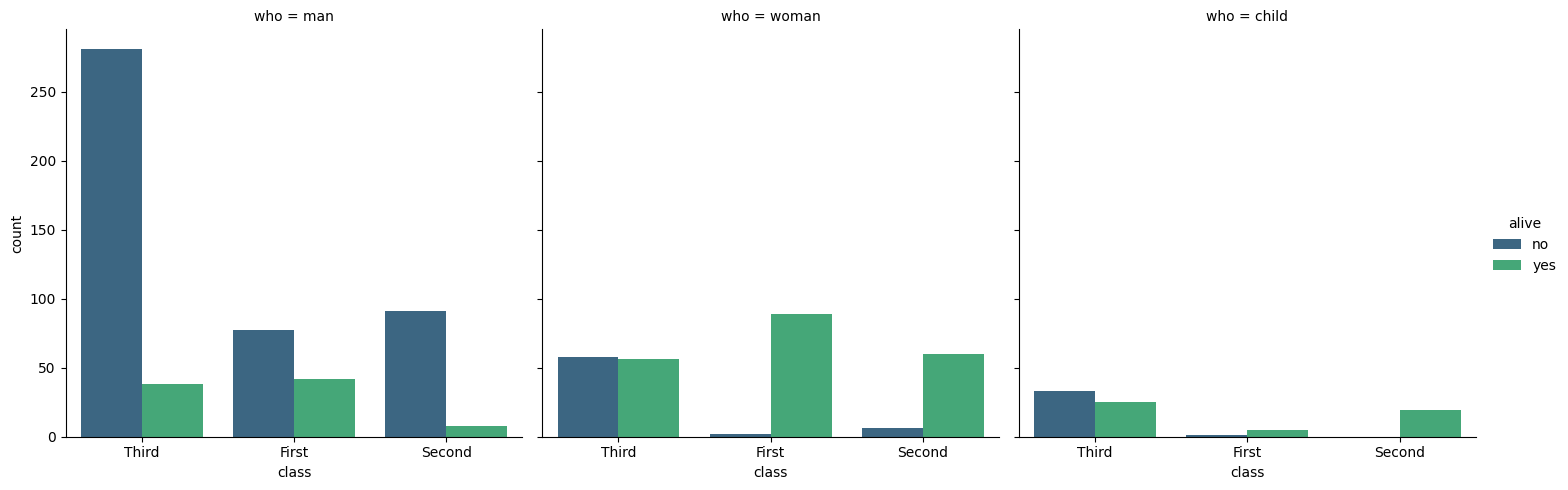

In [44]:
# No usa la función de clase. Lo he copiado de la IA. Comparado con lo que hacen en la solución, no me arrepiento xD
# Supervivencia por Clase y por Sexo.
# Cruzamos Clase vs Supervivencia, pero separado por Sexo/Edad
# Creamos una cuadrícula de gráficos: uno por cada categoría en 'who'
sns.catplot(x="class", hue="alive", col="who", data=df_titanic, kind="count", palette="viridis")
plt.show()

In [45]:
# Existe una jerarquía clara: ser niño otorgaba prioridad, pero esa prioridad estaba fuertemente condicionada por la clase. 
# Un niño en tercera clase tenía muchas menos probabilidades de sobrevivir que un niño (o una mujer) 
# en primera clase. Por tanto, la agrupación más segura en el Titanic fue la de niños y mujeres de 
# primera clase.

Apartado 8

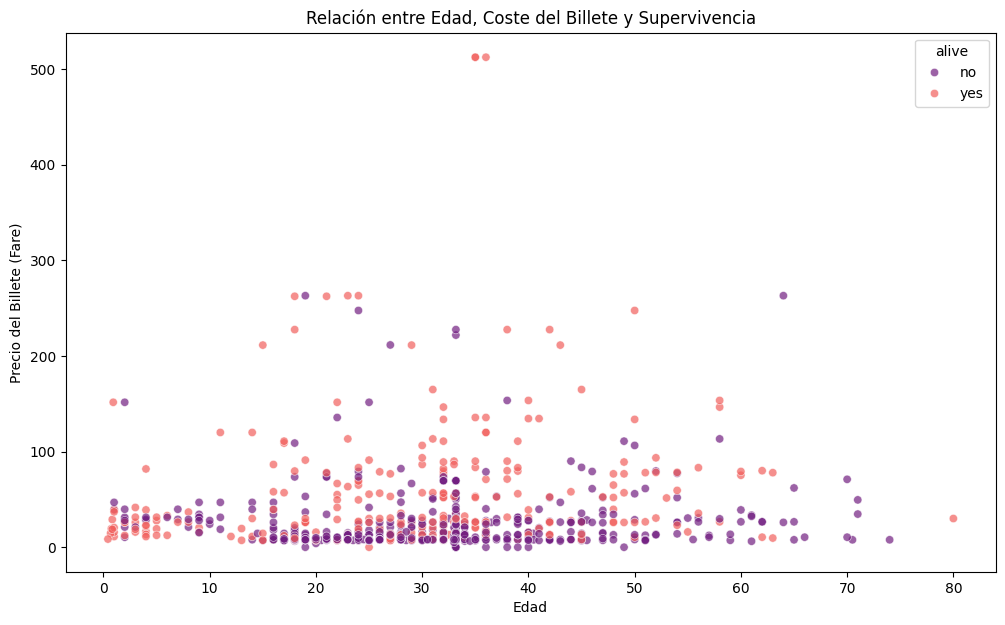

In [53]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x="age", y="fare", hue="alive", data=df_titanic, alpha=0.7, palette="magma")

plt.title("Relación entre Edad, Coste del Billete y Supervivencia")
plt.xlabel("Edad")
plt.ylabel("Precio del Billete (Fare)")
plt.show()

In [54]:
# Conclusión 1: El "Efecto Escudo" del Dinero. Los puntos situados en la parte más alta del eje Y (los que pagaron más de 100-200 libras) son mayoritariamente supervivientes (color de alive=yes), 
# sin importar casi su edad. El dinero fue el factor predictivo más fuerte.

# Conclusión 2: La Supervivencia Infantil. En la parte izquierda del gráfico (edades de 0 a 15 años), vemos una gran concentración de supervivientes, incluso en rangos de precios bajos. 
# Esto confirma que la prioridad por edad funcionó de forma general.

#Conclusión 3: La "Zona de Peligro": La mayor acumulación de fallecidos se encuentra en la base del gráfico (precios bajos, entre 0 y 40 libras) y en edades adultas (entre 20 y 50 años). 
# Aquí es donde la competencia por los botes fue más feroz y las probabilidades eran mínimas si no tenías un billete caro.

## #EXTRA: Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino de completar lo que quedó pendiente en el workout y de entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #EXTRA.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

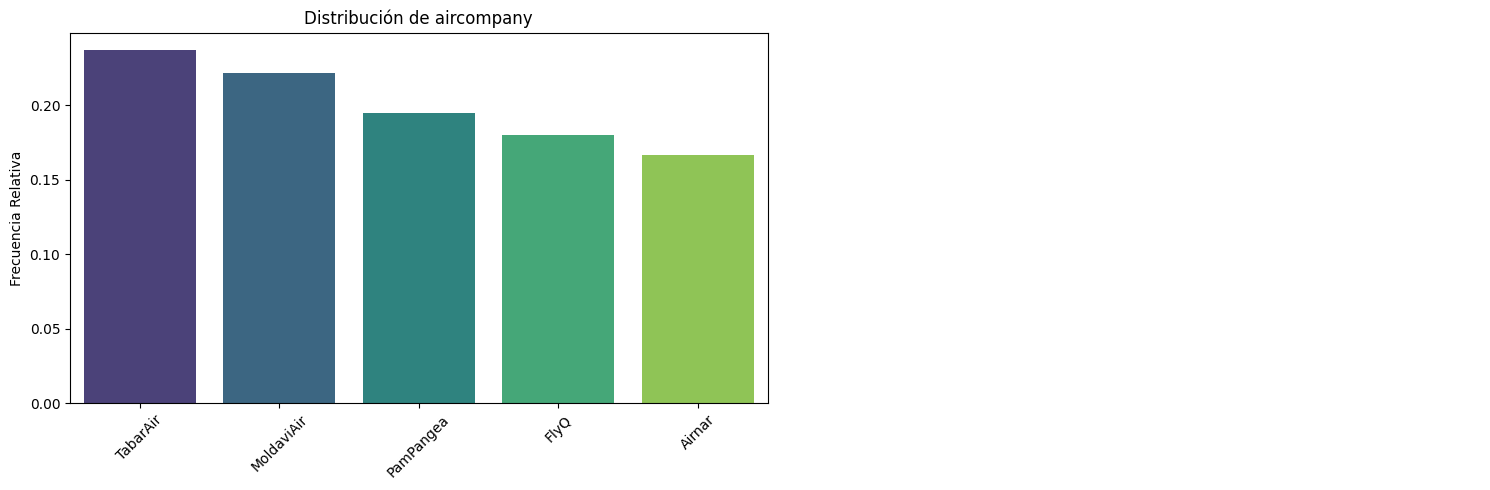

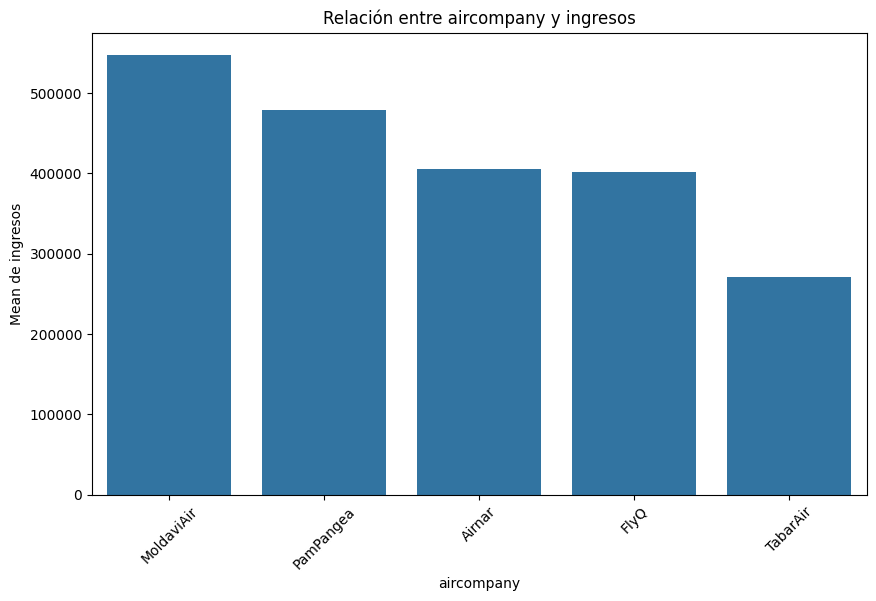

In [61]:
# Carga del dataset (ajusta el nombre del archivo si es necesario)
df_viajes = pd.read_csv("./data/dataset_viajes_jun.csv") 

# 1. Viajes por compañía (Distribución simple)
pinta_distribucion_categoricas(df_viajes, ["aircompany"], relativa=True)

# 2. Análisis bivariante: Aircompany vs Ingresos (Esta debería funcionar bien)
plot_categorical_numerical_relationship(df_viajes, "aircompany", "ingresos")

In [62]:
# CONCLUSIÓN: "Estamos operando muchos vuelos (volumen), pero posiblemente sean trayectos muy cortos 
# o con precios de billetes muy bajos (low cost agresivo), mientras que la competencia está capturando 
# los trayectos más rentables."

### #EXTRA.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

In [64]:
df_viajes.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   aircompany  600 non-null    str    
 1   origen      600 non-null    str    
 2   destino     600 non-null    str    
 3   distancia   600 non-null    int64  
 4   avion       600 non-null    str    
 5   con_escala  600 non-null    bool   
 6   consumo_kg  600 non-null    float64
 7   duracion    600 non-null    int64  
 8   ingresos    600 non-null    float64
 9   id_vuelo    600 non-null    str    
 10  mes         600 non-null    str    
dtypes: bool(1), float64(2), int64(2), str(6)
memory usage: 47.6 KB


Matriz de Correlación:
            ingresos  distancia  consumo_kg
ingresos    1.000000   0.928833    0.944875
distancia   0.928833   1.000000    0.762341
consumo_kg  0.944875   0.762341    1.000000


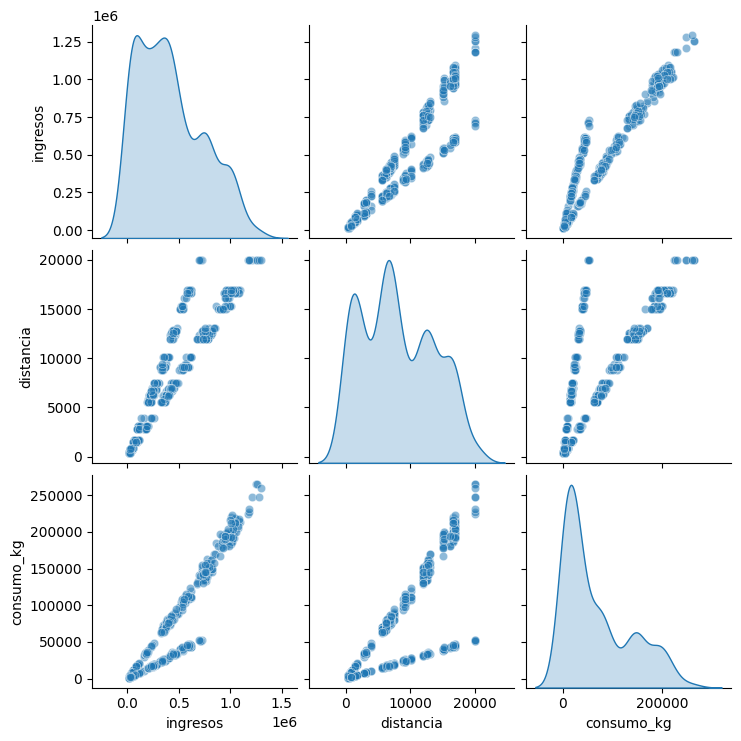

In [65]:
# Definimos las variables a analizar
columnas_num = ["ingresos", "distancia", "consumo_kg"]

# 1. Matriz de correlación para ver los números
print("Matriz de Correlación:")
print(df_viajes[columnas_num].corr())

# 2. Visualización multivariante
sns.pairplot(df_viajes[columnas_num], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.show()

In [66]:
#CONCLUSIÓN: no hay una sola línea, sino que parece que hay dos líneas paralelas. 
# Hay un grupo de vuelos donde el consumo_kg sube muchísimo con la distancia (la línea de arriba).
# Y otro grupo donde el consumo es mucho menor para la misma distancia (la línea de abajo).

### #EXTRA.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Reaiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?

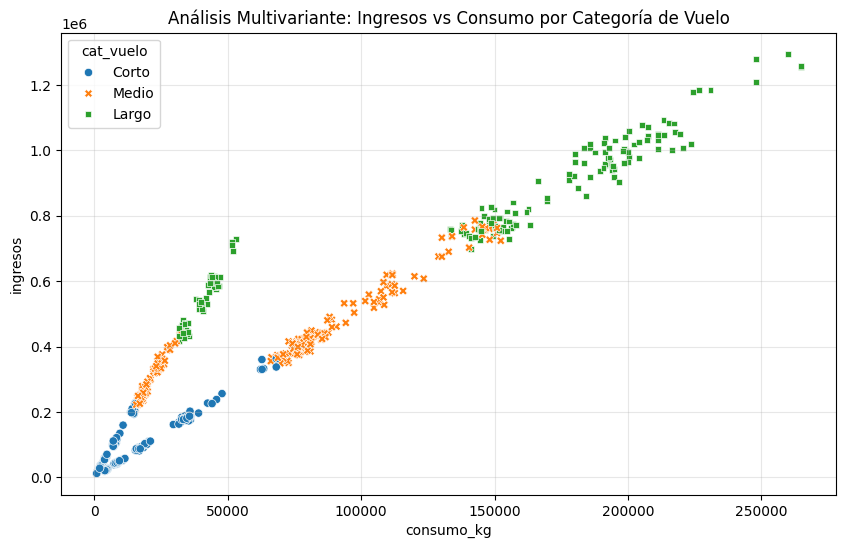

In [67]:
# 1. Creamos la variable 'cat_vuelo' basada en la distancia
# Dividimos en 3 categorías basándonos en los cortes que vemos en tu gráfica
df_viajes['cat_vuelo'] = pd.qcut(df_viajes['distancia'], q=3, labels=['Corto', 'Medio', 'Largo'])

# 2. Análisis multivariante: ¿Qué pasa con los ingresos y el consumo según la categoría?
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_viajes, x="consumo_kg", y="ingresos", hue="cat_vuelo", style="cat_vuelo")
plt.title("Análisis Multivariante: Ingresos vs Consumo por Categoría de Vuelo")
plt.grid(True, alpha=0.3)
plt.show()

In [68]:
# Al realizar el análisis multivariante con cat_vuelo, se observa claramente que la distancia no es el único factor que determina el éxito. 
# Existen dos modelos de rentabilidad distintos en TabarAir. Lo más llamativo es que incluso en vuelos de Largo Alcance, hay una brecha enorme de ingresos para un mismo nivel de consumo. 
# Esto sugiere que el foco del departamento de Data Science debería estar en identificar por qué el grupo superior es tan eficiente y tratar de replicarlo en el resto de la flota."